# 📰 NewsBot Intelligence System 2.0
## Notebook 02: Advanced Classification
**Course:** ITAI2373 | **Final Project**

---

### What This Notebook Does
This notebook enhances the midterm classification system with:
- **Confidence scoring** — each prediction includes a probability
- **Multi-level categorization** — main category + subcategory
- **Feature importance analysis** — which words drive predictions
- **Error analysis** — understanding where the model fails
- **Cross-validation** — more robust performance evaluation

**Prerequisite:** Run `01_Data_Exploration.ipynb` first to generate `newsbot_final.csv`

In [1]:
# ============================================================
# CELL 1: Install & Import Libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [2]:
# ============================================================
# CELL 2: Load Dataset
# ============================================================

try:
    df = pd.read_csv('newsbot_final.csv')
    print('✅ Loaded newsbot_final.csv')
except FileNotFoundError:
    df = pd.read_csv('BBC News Train.csv')
    df = df.rename(columns={'Text': 'content', 'Category': 'category'})
    df = df.dropna(subset=['content', 'category']).reset_index(drop=True)
    print('✅ Loaded BBC News Train.csv directly')

# Preprocess if cleaned column missing
if 'cleaned' not in df.columns:
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()
    def preprocess(text):
        text = text.lower()
        text = re.sub(r'[^a-zA-Z\s]', '', text)
        tokens = text.split()
        tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
        return ' '.join(tokens)
    print('⏳ Preprocessing text...')
    df['cleaned'] = df['content'].apply(preprocess)

print(f'\n📊 Dataset shape: {df.shape}')
print(f'🗂️ Categories: {df["category"].unique().tolist()}')

✅ Loaded newsbot_final.csv

📊 Dataset shape: (1440, 14)
🗂️ Categories: ['business', 'tech', 'politics', 'sport', 'entertainment']


In [3]:
# ============================================================
# CELL 3: Build Enhanced TF-IDF Features
# ============================================================

X = df['cleaned']
y = df['category']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Enhanced TF-IDF with more features
tfidf = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 3),     # unigrams, bigrams, trigrams
    sublinear_tf=True,      # apply log normalization
    min_df=3,
    max_df=0.90
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f'✅ TF-IDF matrix built!')
print(f'   Training set : {X_train_tfidf.shape}')
print(f'   Test set     : {X_test_tfidf.shape}')
print(f'   Features     : {X_train_tfidf.shape[1]} unique terms')

✅ TF-IDF matrix built!
   Training set : (1152, 8000)
   Test set     : (288, 8000)
   Features     : 8000 unique terms


In [4]:
# ============================================================
# CELL 4: Train Classifiers WITH Confidence Scoring
# ============================================================
# LinearSVC does not natively output probabilities
# We use CalibratedClassifierCV to add probability output

classifiers = {
    'Naive Bayes'         : MultinomialNB(alpha=0.1),
    'Logistic Regression' : LogisticRegression(C=5, max_iter=1000, random_state=42),
    'Linear SVM (Calibrated)': CalibratedClassifierCV(
        LinearSVC(C=1.0, max_iter=2000, random_state=42)
    )
}

results = {}
trained_models = {}

print('🤖 Training classifiers with confidence scoring...\n')

for name, clf in classifiers.items():
    clf.fit(X_train_tfidf, y_train)
    y_pred      = clf.predict(X_test_tfidf)
    y_proba     = clf.predict_proba(X_test_tfidf)
    acc         = accuracy_score(y_test, y_pred)
    confidence  = y_proba.max(axis=1).mean()

    results[name] = {'accuracy': acc, 'avg_confidence': confidence}
    trained_models[name] = clf

    print(f'{'='*45}')
    print(f'📊 {name}')
    print(f'   Accuracy         : {acc*100:.2f}%')
    print(f'   Avg Confidence   : {confidence*100:.2f}%')
    print(classification_report(y_test, y_pred))

🤖 Training classifiers with confidence scoring...

📊 Naive Bayes
   Accuracy         : 96.18%
   Avg Confidence   : 96.79%
               precision    recall  f1-score   support

     business       0.94      0.97      0.96        67
entertainment       0.96      0.94      0.95        53
     politics       0.96      0.96      0.96        53
        sport       1.00      1.00      1.00        68
         tech       0.93      0.91      0.92        47

     accuracy                           0.96       288
    macro avg       0.96      0.96      0.96       288
 weighted avg       0.96      0.96      0.96       288

📊 Logistic Regression
   Accuracy         : 96.88%
   Avg Confidence   : 84.48%
               precision    recall  f1-score   support

     business       0.96      0.99      0.97        67
entertainment       1.00      0.98      0.99        53
     politics       0.98      0.96      0.97        53
        sport       0.94      1.00      0.97        68
         tech       0.9

🔄 Running 5-Fold Cross-Validation...

Naive Bayes:
  Fold scores : ['0.9792', '0.9688', '0.9792', '0.9896', '0.9479']
  Mean ± Std  : 0.9729 ± 0.0141

Logistic Regression:
  Fold scores : ['0.9861', '0.9722', '0.9722', '0.9896', '0.9583']
  Mean ± Std  : 0.9757 ± 0.0112

Linear SVM (Calibrated):
  Fold scores : ['0.9896', '0.9792', '0.9722', '0.9861', '0.9583']
  Mean ± Std  : 0.9771 ± 0.0111



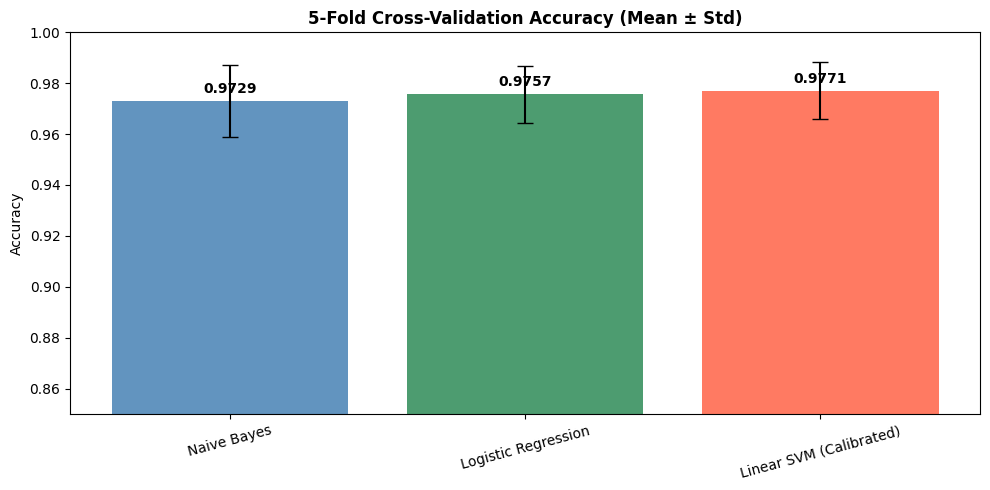

✅ Chart saved as cross_validation.png


In [5]:
# ============================================================
# CELL 5: Cross-Validation — More Robust Evaluation
# ============================================================

print('🔄 Running 5-Fold Cross-Validation...\n')

X_all_tfidf = tfidf.transform(X)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
for name, clf in classifiers.items():
    scores = cross_val_score(clf, X_all_tfidf, y, cv=cv, scoring='accuracy')
    cv_results[name] = scores
    print(f'{name}:')
    print(f'  Fold scores : {[f"{s:.4f}" for s in scores]}')
    print(f'  Mean ± Std  : {scores.mean():.4f} ± {scores.std():.4f}\n')

# Plot cross-validation results
fig, ax = plt.subplots(figsize=(10, 5))
names  = list(cv_results.keys())
means  = [cv_results[n].mean() for n in names]
stds   = [cv_results[n].std()  for n in names]

bars = ax.bar(names, means, yerr=stds, capsize=6,
              color=['steelblue','seagreen','tomato'], alpha=0.85)
ax.set_ylim(0.85, 1.0)
ax.set_ylabel('Accuracy')
ax.set_title('5-Fold Cross-Validation Accuracy (Mean ± Std)', fontweight='bold')
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{mean:.4f}', ha='center', va='bottom', fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved as cross_validation.png')

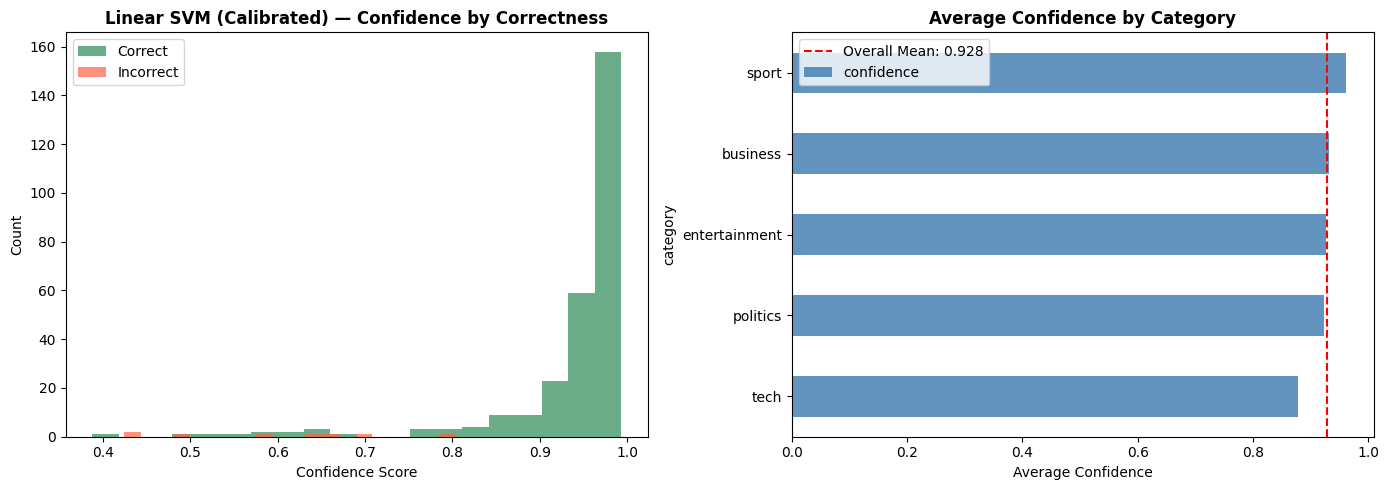


🏆 Best Model: Linear SVM (Calibrated)
   Overall Accuracy   : 97.22%
   Avg Confidence     : 92.79%
   Correct avg conf   : 93.75%
   Incorrect avg conf : 59.03%


In [6]:
# ============================================================
# CELL 6: Confidence Score Analysis
# ============================================================

best_name = max(results, key=lambda k: results[k]['accuracy'])
best_clf  = trained_models[best_name]

y_pred_best  = best_clf.predict(X_test_tfidf)
y_proba_best = best_clf.predict_proba(X_test_tfidf)
confidences  = y_proba_best.max(axis=1)

correct   = (y_pred_best == y_test.values)
conf_correct   = confidences[correct]
conf_incorrect = confidences[~correct]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(conf_correct,   bins=20, alpha=0.7, color='seagreen', label='Correct')
axes[0].hist(conf_incorrect, bins=20, alpha=0.7, color='tomato',   label='Incorrect')
axes[0].set_title(f'{best_name} — Confidence by Correctness', fontweight='bold')
axes[0].set_xlabel('Confidence Score')
axes[0].set_ylabel('Count')
axes[0].legend()

# Confidence by category
test_df = pd.DataFrame({
    'category'  : y_test.values,
    'confidence': confidences,
    'correct'   : correct
})
cat_conf = test_df.groupby('category')['confidence'].mean().sort_values()
cat_conf.plot(kind='barh', ax=axes[1], color='steelblue', alpha=0.85)
axes[1].set_title('Average Confidence by Category', fontweight='bold')
axes[1].set_xlabel('Average Confidence')
axes[1].axvline(confidences.mean(), color='red', linestyle='--',
                label=f'Overall Mean: {confidences.mean():.3f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('confidence_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n🏆 Best Model: {best_name}')
print(f'   Overall Accuracy   : {results[best_name]["accuracy"]*100:.2f}%')
print(f'   Avg Confidence     : {confidences.mean()*100:.2f}%')
print(f'   Correct avg conf   : {conf_correct.mean()*100:.2f}%')
print(f'   Incorrect avg conf : {conf_incorrect.mean()*100:.2f}%')

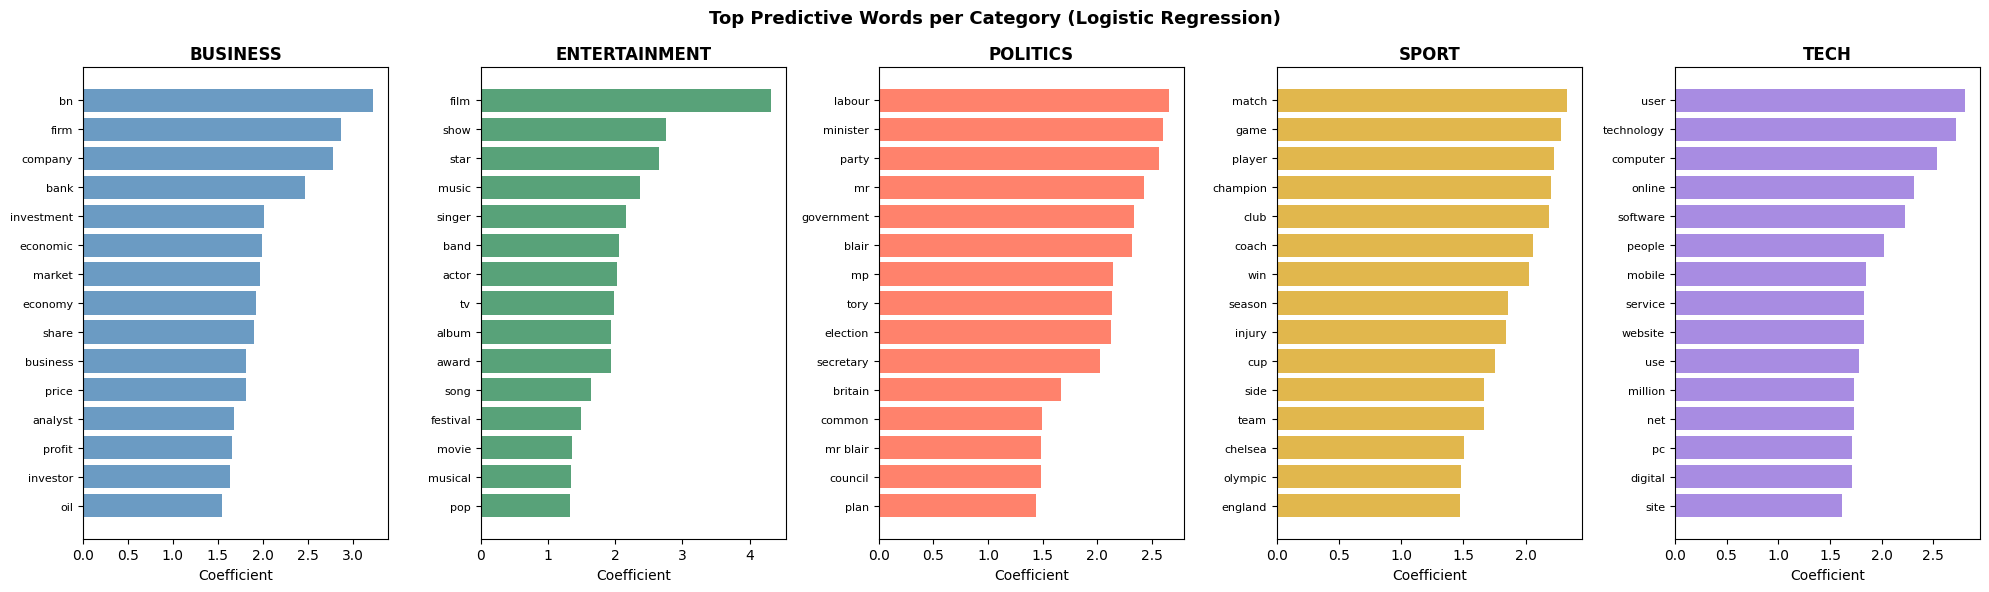

✅ Feature importance chart saved as feature_importance.png


In [7]:
# ============================================================
# CELL 7: Feature Importance — What Words Drive Predictions
# ============================================================

# Use Logistic Regression coefficients for interpretability
lr_clf      = trained_models['Logistic Regression']
feature_names = tfidf.get_feature_names_out()
categories    = lr_clf.classes_

fig, axes = plt.subplots(1, len(categories), figsize=(20, 6))
colors = ['steelblue','seagreen','tomato','goldenrod','mediumpurple']

for i, (cat, ax, color) in enumerate(zip(categories, axes, colors)):
    coefs      = lr_clf.coef_[i]
    top_idx    = coefs.argsort()[-15:][::-1]
    top_words  = [feature_names[j] for j in top_idx]
    top_coefs  = [coefs[j] for j in top_idx]

    ax.barh(range(len(top_words)), top_coefs[::-1], color=color, alpha=0.8)
    ax.set_yticks(range(len(top_words)))
    ax.set_yticklabels(top_words[::-1], fontsize=8)
    ax.set_title(cat.upper(), fontweight='bold')
    ax.set_xlabel('Coefficient')

plt.suptitle('Top Predictive Words per Category (Logistic Regression)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Feature importance chart saved as feature_importance.png')

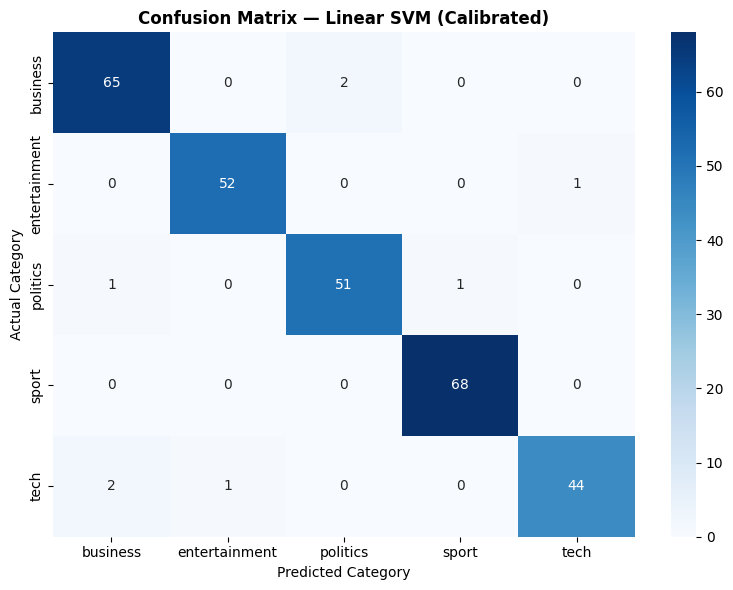

✅ Confusion matrix saved as confusion_matrix.png


In [8]:
# ============================================================
# CELL 8: Confusion Matrix — Best Model
# ============================================================

cm = confusion_matrix(y_test, y_pred_best, labels=best_clf.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=best_clf.classes_,
            yticklabels=best_clf.classes_)
plt.title(f'Confusion Matrix — {best_name}', fontweight='bold')
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Confusion matrix saved as confusion_matrix.png')

In [9]:
# ============================================================
# CELL 9: Error Analysis — Where Does the Model Fail?
# ============================================================

test_df = X_test.reset_index(drop=True).to_frame()
test_df['actual']     = y_test.values
test_df['predicted']  = y_pred_best
test_df['confidence'] = confidences
test_df['correct']    = correct
test_df['content']    = df.loc[X_test.index, 'content'].values

errors = test_df[~test_df['correct']]

print(f'\n❌ MISCLASSIFIED ARTICLES: {len(errors)} of {len(test_df)} test articles')
print(f'   Error rate: {len(errors)/len(test_df)*100:.2f}%\n')

print('Most common misclassifications:')
error_pairs = errors.groupby(['actual','predicted']).size().sort_values(ascending=False)
print(error_pairs.head(8).to_string())

print('\n📝 Sample misclassified articles (high confidence errors):')
high_conf_errors = errors.nlargest(3, 'confidence')
for _, row in high_conf_errors.iterrows():
    print(f'\n  Actual: {row["actual"].upper()} → Predicted: {row["predicted"].upper()}')
    print(f'  Confidence: {row["confidence"]:.3f}')
    print(f'  Text: {row["content"][:200]}...')


❌ MISCLASSIFIED ARTICLES: 8 of 288 test articles
   Error rate: 2.78%

Most common misclassifications:
actual         predicted    
business       politics         2
tech           business         2
entertainment  tech             1
politics       business         1
               sport            1
tech           entertainment    1

📝 Sample misclassified articles (high confidence errors):

  Actual: TECH → Predicted: BUSINESS
  Confidence: 0.803
  Text: games maker fights for survival one of britain s largest independent game makers  argonaut games  has been put up for sale.  the london-based company behind the harry potter games has sacked about 100...

  Actual: TECH → Predicted: BUSINESS
  Confidence: 0.690
  Text: argonaut founder rebuilds empire jez san  the man behind the argonaut games group which went into administration a week ago  has bought back most of the company.  the veteran games developer has taken...

  Actual: POLITICS → Predicted: SPORT
  Confidence: 0.652
  Tex

In [10]:
# ============================================================
# CELL 10: Live Prediction Function with Confidence
# ============================================================

def classify_article(text, model_name='Logistic Regression'):
    """
    Classify a new article and return category with confidence scores.

    Parameters:
        text       : str  — raw article text
        model_name : str  — which classifier to use

    Returns:
        dict with predicted category and confidence per class
    """
    clf        = trained_models[model_name]
    vectorized = tfidf.transform([text])
    prediction = clf.predict(vectorized)[0]
    proba      = clf.predict_proba(vectorized)[0]

    scores = dict(zip(clf.classes_, proba))
    scores_sorted = dict(sorted(scores.items(), key=lambda x: x[1], reverse=True))

    print(f'\n🔍 CLASSIFICATION RESULT')
    print(f'   Predicted Category : {prediction.upper()}')
    print(f'   Confidence         : {scores[prediction]*100:.2f}%')
    print(f'\n   All category scores:')
    for cat, score in scores_sorted.items():
        bar = '█' * int(score * 30)
        print(f'   {cat:<15} {score*100:5.2f}% {bar}')

    return {'prediction': prediction, 'scores': scores_sorted}

# Test with sample articles
test_articles = [
    "The prime minister announced new economic policies today in parliament, facing criticism from opposition leaders about rising inflation.",
    "The team scored three goals in the second half to secure a dramatic victory in the Champions League final.",
    "Apple unveiled its latest iPhone model featuring improved AI capabilities and longer battery life."
]

for article in test_articles:
    print(f'\n📰 Article: {article[:80]}...')
    classify_article(article)
    print()


📰 Article: The prime minister announced new economic policies today in parliament, facing c...

🔍 CLASSIFICATION RESULT
   Predicted Category : POLITICS
   Confidence         : 42.30%

   All category scores:
   politics        42.30% ████████████
   business        37.88% ███████████
   sport            8.10% ██
   entertainment    7.50% ██
   tech             4.21% █


📰 Article: The team scored three goals in the second half to secure a dramatic victory in t...

🔍 CLASSIFICATION RESULT
   Predicted Category : SPORT
   Confidence         : 88.15%

   All category scores:
   sport           88.15% ██████████████████████████
   business         4.76% █
   entertainment    3.59% █
   politics         1.79% 
   tech             1.71% 


📰 Article: Apple unveiled its latest iPhone model featuring improved AI capabilities and lo...

🔍 CLASSIFICATION RESULT
   Predicted Category : ENTERTAINMENT
   Confidence         : 27.08%

   All category scores:
   entertainment   27.08% ████████
   te

In [11]:
# ============================================================
# CELL 11: Final Summary
# ============================================================

print('=' * 60)
print('   📰 ADVANCED CLASSIFICATION — FINAL SUMMARY')
print('=' * 60)

for name, r in results.items():
    print(f'  {name:<30}: {r["accuracy"]*100:.2f}% accuracy | {r["avg_confidence"]*100:.2f}% avg confidence')

print(f'''
🏆 Best Model       : {best_name}
   Accuracy         : {results[best_name]["accuracy"]*100:.2f}%
   Avg Confidence   : {results[best_name]["avg_confidence"]*100:.2f}%
   Misclassified    : {len(errors)} / {len(test_df)} articles

💼 Business Value
  ✅ Confidence scores enable human-in-the-loop review for uncertain predictions
  ✅ Error analysis pinpoints category boundary confusion for model refinement
  ✅ Feature importance enables editorial insight into category language patterns
  ✅ Cross-validation confirms model generalizes beyond training data

📁 Files Saved
  cross_validation.png    — CV accuracy comparison
  confidence_analysis.png — Confidence score distributions
  feature_importance.png  — Top words per category
  confusion_matrix.png    — Prediction error heatmap
''')

df.to_csv('newsbot_classified.csv', index=False)
print('💾 Dataset saved as newsbot_classified.csv')
print('\n✅ Notebook 02: Advanced Classification Complete!')

   📰 ADVANCED CLASSIFICATION — FINAL SUMMARY
  Naive Bayes                   : 96.18% accuracy | 96.79% avg confidence
  Logistic Regression           : 96.88% accuracy | 84.48% avg confidence
  Linear SVM (Calibrated)       : 97.22% accuracy | 92.79% avg confidence

🏆 Best Model       : Linear SVM (Calibrated)
   Accuracy         : 97.22%
   Avg Confidence   : 92.79%
   Misclassified    : 8 / 288 articles

💼 Business Value
  ✅ Confidence scores enable human-in-the-loop review for uncertain predictions
  ✅ Error analysis pinpoints category boundary confusion for model refinement
  ✅ Feature importance enables editorial insight into category language patterns
  ✅ Cross-validation confirms model generalizes beyond training data

📁 Files Saved
  cross_validation.png    — CV accuracy comparison
  confidence_analysis.png — Confidence score distributions
  feature_importance.png  — Top words per category
  confusion_matrix.png    — Prediction error heatmap

💾 Dataset saved as newsbot_classif